# 산학프로젝트
**제조 공정 품질 불량 예측**

# 04_6_AutoEncoder_CV_Validation

- 입력 데이터: 02_EDA가 저장한 `labeled_modeling.csv`
- 최종 성능 추정 (보고 수치)
- 평가 프로토콜: 전체 5230건 5-fold × 3반복(fold 15개), fold 안에서 오토인코더 재학습
- 주의: 보고서와 대시보드에 쓰는 수치는 **이 노트북에서만** 가져옴

## import

In [1]:
import pandas as pd
import numpy as np
import os

# 검사 물량 표가 70행이라 기본 설정으로는 가운데가 생략됨
pd.set_option('display.max_rows', 100)

## 경로설정

In [2]:
os.chdir("data")

## 데이터 불러오기

In [3]:
# 02_EDA에서 저장한 전처리 데이터
# - 기록 오류 보정, 중복 제거, CN7·RG3 한정, PassOrFail 인코딩(양품 0 / 불량 1), Part 파생까지 끝난 상태
model_data=pd.read_csv('labeled_modeling.csv', index_col=0)

print(f'{model_data.shape[0]}행 {model_data.shape[1]}컬럼 / 불량 {int(model_data["PassOrFail"].sum())}건')

5230행 30컬럼 / 불량 60건


In [4]:
# 교차검증 관련 라이브러리
from pathlib import Path
import sys

import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from scipy.stats import wilcoxon
from sklearn import set_config
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import average_precision_score, precision_score, recall_score, f1_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from xgboost import XGBClassifier

# 오토인코더 관련 라이브러리
import keras
from keras import Sequential
from keras.layers import Dense, Input
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'data' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 공통 평가 함수
from utils.model_evaluation import recall_at_k_table

set_config(display='text')

# 그래프 한글 표시
plt.rcParams['font.family']='Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False

## 데이터 전처리

In [5]:
# 식별 컬럼 제외
drop_columns=['TimeStamp', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL', 'PART_NAME', 'EQUIP_CD']

final_df=model_data.drop(columns=drop_columns)

X_part=final_df.drop(columns='PassOrFail')
Y=final_df['PassOrFail']

# 더미변수 생성
X_part = pd.get_dummies(data = X_part, columns = ['Part'], drop_first=True, dtype=int)

# 04_5는 80% 학습 + holdout 평가, 여기서는 전체 데이터를 fold로 나눠 평가
print(f'전체: {X_part.shape}, 불량 수: {Y.sum()}')

전체: (5230, 26), 불량 수: 60


## 오토인코더 설정

- 04_5에서 라벨 없이 선택한 구조 `27 → 20 → 12 → 20 → 27`을 그대로 사용
- 학습 설정도 04_5와 동일. fold마다 새로 학습하고 시드 2개의 복원 오차를 평균
- `validation_split=0.2`는 마지막 20% 행을 검증셋으로 쓰는데 원본 데이터가 부품별로 뭉쳐 있으므로, 학습 행을 먼저 섞어서 입력

In [6]:
# fold마다 오토인코더를 다시 학습해 원본과 짝지어 비교한다.
# 최종 결론은 미적용이지만, 그 근거 표를 보정 후 데이터로 다시 만들기 위해 켜 둔다.
RUN_AUTOENCODER=True

ae_hidden_units=[20]
ae_latent_units=12
ae_seeds=[0, 1]


def build_ae(hidden_units, latent_units, n_features, seed=0):
    keras.utils.set_random_seed(seed)

    encoder=Sequential([Dense(units, activation='relu') for units in hidden_units]
                       +[Dense(latent_units, activation='relu')], name='encoder')
    decoder=Sequential([Dense(units, activation='relu') for units in reversed(hidden_units)]
                       +[Dense(n_features, activation='sigmoid')], name='decoder')

    ae=Sequential([Input(shape=(n_features,)), encoder, decoder], name='autoencoder')
    ae.compile(loss='mse', optimizer=Adam(learning_rate=0.001))
    return ae


def fit_ae(ae, x):
    return ae.fit(x, x, batch_size=64, epochs=400, validation_split=0.2, verbose=0,
                  callbacks=[EarlyStopping(monitor='val_loss', patience=30, mode='min', restore_best_weights=True)])


def recon_error(x, ae_list, scaler):
    scaled=scaler.transform(x)
    errors=[np.mean(np.square(ae.predict(scaled, verbose=0)-scaled), axis=1) for ae in ae_list]
    return np.mean(errors, axis=0)

## 모델 설정

- 04_2 Grid Search가 선택한 파라미터를 고정. fold 안에서 재튜닝하지 않음
- XGBoost 계열은 04_1에서 AP 기준으로 후보에서 빠졌으나, 04_2 OOF의 검사 물량 기준으로는 상위권이라 함께 검증
- XGBoost 파라미터는 04_1과 같게 두고 Grid Search는 하지 않음

In [7]:
model_dict={
    'RandomForest Balanced': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('rf', RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=2, min_samples_leaf=4,
                                      class_weight='balanced', n_jobs=-1, random_state=0)),
    ]),
    'RandomForest SMOTE St=0.1': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('smote', SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)),
        ('rf', RandomForestClassifier(n_estimators=300, max_depth=20, min_samples_split=2, min_samples_leaf=1,
                                      n_jobs=-1, random_state=0)),
    ]),
    'Bagging SMOTE St=0.1': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('smote', SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)),
        ('bagging', BaggingClassifier(n_estimators=500, max_samples=0.5, max_features=0.5, n_jobs=-1, random_state=0)),
    ]),
    'XGBoost': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('xgb', XGBClassifier(n_estimators=1000, random_state=0)),
    ]),
    'XGBoost SMOTE St=0.1': Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('smote', SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)),
        ('xgb', XGBClassifier(n_estimators=1000, random_state=0)),
    ]),
}


def score_model(y, proba):
    pred=(proba>=0.5).astype(int)
    return {
        'Average Precision': average_precision_score(y, proba),
        'Defect Precision': precision_score(y, pred, zero_division=0),
        'Defect Recall': recall_score(y, pred, zero_division=0),
        'Defect F1 Score': f1_score(y, pred, zero_division=0),
    }

## 1. Fold 안에서 오토인코더 재학습

- 5-fold × 3반복으로 분할 시드를 바꿔 fold 15개 생성
- 각 fold의 학습 부분 양품만으로 오토인코더를 다시 학습, 평가 부분은 transform도 하지 않음
- 같은 fold에서 원본 27개 특성과 원본 + Recon_Error를 짝지어 평가

In [8]:
n_splits=5
n_repeats=3

cv=RepeatedStratifiedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=0)
cv_splits=list(cv.split(X_part, Y))

fold_rows=[]

# 반복 1회는 fold 5개가 전체 데이터를 한 번씩 덮으므로, 검사 물량 기준 지표를 위해 반복 단위로 확률을 모아 둠
oof_proba_store={}
for fold, (train_idx, test_idx) in enumerate(cv_splits, start=1):
    x_tr, x_te=X_part.iloc[train_idx], X_part.iloc[test_idx]
    y_tr, y_te=Y.iloc[train_idx], Y.iloc[test_idx]

    feature_sets={'원본': (x_tr, x_te)}
    fold_val_losses=[np.nan]
    recon_te=None

    if RUN_AUTOENCODER:
        # 이 fold의 학습 부분 양품만으로 오토인코더 재학습 (검증셋 편중을 막기 위해 행을 섞음)
        x_tr_normal=x_tr[y_tr==0].sample(frac=1, random_state=0)
        fold_scaler=MinMaxScaler().fit(x_tr_normal)
        x_tr_normal_scaled=fold_scaler.transform(x_tr_normal)

        fold_ae_list=[]
        fold_val_losses=[]
        for seed in ae_seeds:
            ae=build_ae(ae_hidden_units, ae_latent_units, X_part.shape[1], seed=seed)
            history=fit_ae(ae, x_tr_normal_scaled)
            fold_ae_list.append(ae)
            fold_val_losses.append(min(history.history['val_loss']))

        recon_tr=recon_error(x_tr, fold_ae_list, fold_scaler)
        recon_te=recon_error(x_te, fold_ae_list, fold_scaler)

        # 같은 fold에서 원본과 AE 특성을 짝지어 평가
        feature_sets['AE Recon Error']=(x_tr.assign(Recon_Error=recon_tr),
                                        x_te.assign(Recon_Error=recon_te))

    repeat=(fold-1)//n_splits+1

    for set_name, (xt, xe) in feature_sets.items():
        for model_name, model in model_dict.items():
            estimator=clone(model)
            estimator.fit(xt, y_tr)
            proba=estimator.predict_proba(xe)[:, 1]

            fold_rows.append({
                'Model': model_name,
                'Feature Set': set_name,
                'Fold': fold,
                'Repeat': repeat,
                **score_model(y_te, proba),
            })

            key=(model_name, set_name, repeat)
            oof_proba_store.setdefault(key, np.full(len(Y), np.nan))[test_idx]=proba

    if RUN_AUTOENCODER:
        print(f'fold {fold}/{len(cv_splits)} 완료 | AE val_loss {np.mean(fold_val_losses):.6f} | '
              f'복원 오차 단독 AP {average_precision_score(y_te, recon_te):.4f}')
    else:
        print(f'fold {fold}/{len(cv_splits)} 완료 (오토인코더 생략)')

fold_df=pd.DataFrame(fold_rows)
fold_df.head()

fold 1/15 완료 | AE val_loss 0.000179 | 복원 오차 단독 AP 0.2133


fold 2/15 완료 | AE val_loss 0.000111 | 복원 오차 단독 AP 0.1109


fold 3/15 완료 | AE val_loss 0.000150 | 복원 오차 단독 AP 0.3693


fold 4/15 완료 | AE val_loss 0.000112 | 복원 오차 단독 AP 0.2651


fold 5/15 완료 | AE val_loss 0.000150 | 복원 오차 단독 AP 0.0580


...

fold 12/15 완료 | AE val_loss 0.000152 | 복원 오차 단독 AP 0.2715


fold 13/15 완료 | AE val_loss 0.000110 | 복원 오차 단독 AP 0.1090


fold 14/15 완료 | AE val_loss 0.000176 | 복원 오차 단독 AP 0.1638


fold 15/15 완료 | AE val_loss 0.000114 | 복원 오차 단독 AP 0.1619


,Model,Feature Set,Fold,Repeat,Average Precision,Defect Precision,Defect Recall,Defect F1 Score
0,RandomForest Balanced,원본,1,1,0.440638,0.240000,0.500000,0.324324
1,RandomForest SMOTE St=0.1,원본,1,1,0.427215,0.571429,0.333333,0.421053
2,Bagging SMOTE St=0.1,원본,1,1,0.413029,0.571429,0.333333,0.421053
3,XGBoost,원본,1,1,0.454594,0.800000,0.333333,0.470588
4,XGBoost SMOTE St=0.1,원본,1,1,0.470614,0.666667,0.333333,0.444444


## 2. fold 평균 성능

In [9]:
metrics=['Average Precision', 'Defect Precision', 'Defect Recall', 'Defect F1 Score']

summary_df=fold_df.groupby(['Model', 'Feature Set'])[metrics].agg(['mean', 'std'])
summary_df.columns=[f'{metric} {stat}' for metric, stat in summary_df.columns]
summary_df.round(4)

Average Precision mean  \
Model                     Feature Set                              
Bagging SMOTE St=0.1      AE Recon Error                  0.3725   
                          원본                              0.3543   
RandomForest Balanced     AE Recon Error                  0.3963   
                          원본                              0.3931   
RandomForest SMOTE St=0.1 AE Recon Error                  0.3716   
                          원본                              0.3504   
XGBoost                   AE Recon Error                  0.3816   
                          원본                              0.3480   
XGBoost SMOTE St=0.1      AE Recon Error                  0.3596   
                          원본                              0.3529   

                                          Average Precision std  \
Model                     Feature Set                             
Bagging SMOTE St=0.1      AE Recon Error                 0.1173   
                          원본                             0.1227   
RandomForest Balanced     AE Recon Error                 0.1028   
                          원본                             0.1107   
RandomForest SMOTE St=0.1 AE Recon Error                 0.1070   
                          원본                             0.1160   
XGBoost                   AE Recon Error                 0.1100   
                          원본                             0.0958   
XGBoost SMOTE St=0.1      AE Recon Error                 0.1147   
                          원본                             0.1018   

                                          Defect Precision mean  \
Model                     Feature Set                             
Bagging SMOTE St=0.1      AE Recon Error                 0.6259   
                          원본                             0.6700   
RandomForest Balanced     AE Recon Error                 0.2740   
                          원본                             0.2335   
RandomForest SMOTE St=0.1 AE Recon Error                 0.6013   
                          원본                             0.6049   
XGBoost                   AE Recon Error                 0.6230   
                          원본                             0.6555   
XGBoost SMOTE St=0.1      AE Recon Error                 0.5793   
                          원본                             0.5824   

                                          Defect Precision std  \
Model                     Feature Set                            
Bagging SMOTE St=0.1      AE Recon Error                0.2152   
                          원본                            0.2990   
RandomForest Balanced     AE Recon Error                0.0763   
                          원본                            0.0615   
RandomForest SMOTE St=0.1 AE Recon Error                0.2515   
                          원본                            0.2468   
XGBoost                   AE Recon Error                0.2132   
                          원본                            0.2230   
XGBoost SMOTE St=0.1      AE Recon Error                0.2022   
                          원본                            0.2086   

                                          Defect Recall mean  \
Model                     Feature Set                          
Bagging SMOTE St=0.1      AE Recon Error              0.2556   
                          원본                          0.2500   
RandomForest Balanced     AE Recon Error              0.3944   
                          원본                          0.3944   
RandomForest SMOTE St=0.1 AE Recon Error              0.2556   
                          원본                          0.2556   
XGBoost                   AE Recon Error              0.2611   
                          원본                          0.2611   
XGBoost SMOTE St=0.1      AE Recon Error              0.2611   
                          원본                          0.2667   

                                          Defect Reca

## 3. 짝차이 (AE Recon Error - 원본)

- 같은 fold, 같은 모델끼리만 비교
- fold 15개 중 몇 개에서 개선됐는지가 핵심
- 평균은 특정 fold에 끌릴 수 있어 중앙값도 함께 확인

In [10]:
if RUN_AUTOENCODER:
    pivot_df=fold_df.pivot_table(index=['Model', 'Fold'], columns='Feature Set', values=metrics)
    delta_df=pd.DataFrame({metric: pivot_df[(metric, 'AE Recon Error')]-pivot_df[(metric, '원본')] for metric in metrics})

    delta_summary=delta_df.groupby('Model').agg(['mean', 'median', 'std'])
    delta_summary.columns=[f'{metric} {stat}' for metric, stat in delta_summary.columns]
    display(delta_summary.round(4))
else:
    print('오토인코더 생략 (RUN_AUTOENCODER=False). 짝비교 결과는 해석 6절 참고')

,Average Precision mean,Average Precision median,Average Precision std,Defect Precision mean,Defect Precision median,Defect Precision std,Defect Recall mean,Defect Recall median,Defect Recall std,Defect F1 Score mean,Defect F1 Score median,Defect F1 Score std
Model,,,,,,,,,,,,
Bagging SMOTE St=0.1,0.0182,0.0061,0.0279,-0.0441,0.0000,0.1883,0.0056,0.0,0.0215,0.0022,0.0000,0.0411
RandomForest Balanced,0.0032,0.0011,0.0331,0.0405,0.0368,0.0510,-0.0000,0.0,0.0630,0.0269,0.0196,0.0500
RandomForest SMOTE St=0.1,0.0212,0.0113,0.0337,-0.0036,0.0000,0.0573,0.0000,0.0,0.0000,0.0012,0.0000,0.0102
XGBoost,0.0336,0.0331,0.0332,-0.0325,0.0000,0.2521,0.0000,0.0,0.0315,-0.0024,0.0000,0.0452
XGBoost SMOTE St=0.1,0.0067,0.0038,0.0375,-0.0031,0.0000,0.2174,-0.0056,0.0,0.0381,-0.0047,0.0000,0.0689


In [11]:
if RUN_AUTOENCODER:
    check_rows=[]
    for model_name, group in delta_df.groupby('Model'):
        ap_delta=group['Average Precision']
        p_value=wilcoxon(ap_delta)[1] if (ap_delta!=0).any() else np.nan

        check_rows.append({
            'Model': model_name,
            'AP 개선 fold': f'{(ap_delta>0).sum()}/{len(ap_delta)}',
            'AP 평균 변화': ap_delta.mean(),
            'AP 중앙값 변화': ap_delta.median(),
            'AP 변화 표준편차': ap_delta.std(),
            'Wilcoxon p (참고)': p_value,
        })

    display(pd.DataFrame(check_rows))
else:
    print('오토인코더 생략')

,Model,AP 개선 fold,AP 평균 변화,AP 중앙값 변화,AP 변화 표준편차,Wilcoxon p (참고)
0,Bagging SMOTE St=0.1,10/15,0.018180,0.006087,0.027857,0.072998
1,RandomForest Balanced,8/15,0.003166,0.001130,0.033141,0.678772
2,RandomForest SMOTE St=0.1,11/15,0.021180,0.011301,0.033670,0.030151
3,XGBoost,14/15,0.033568,0.033085,0.033219,0.002014
4,XGBoost SMOTE St=0.1,8/15,0.006672,0.003826,0.037487,0.599487


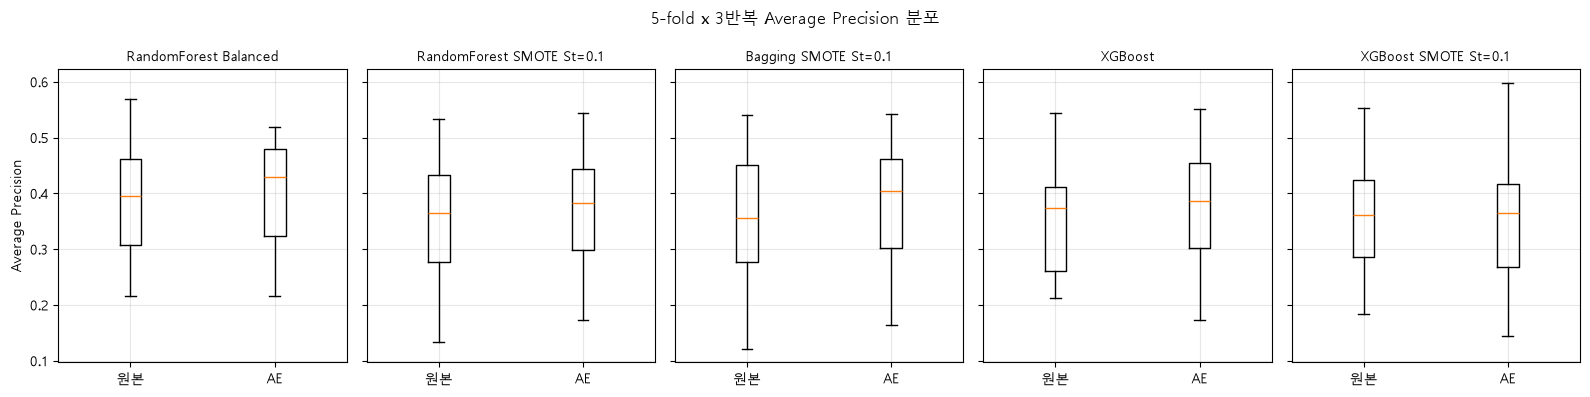

In [12]:
if RUN_AUTOENCODER:
    fig, axes=plt.subplots(1, len(model_dict), figsize=(3.2*len(model_dict), 4), sharey=True)

    for ax, model_name in zip(axes, model_dict):
        model_df=fold_df[fold_df['Model']==model_name]
        ax.boxplot([model_df[model_df['Feature Set']==set_name]['Average Precision'] for set_name in ['원본', 'AE Recon Error']],
                   tick_labels=['원본', 'AE'])
        ax.set_title(model_name, fontsize=10)
        ax.grid(alpha=0.3)

    axes[0].set_ylabel('Average Precision')
    plt.suptitle('5-fold x 3반복 Average Precision 분포')
    plt.tight_layout()
    plt.show()
else:
    print('오토인코더 생략')

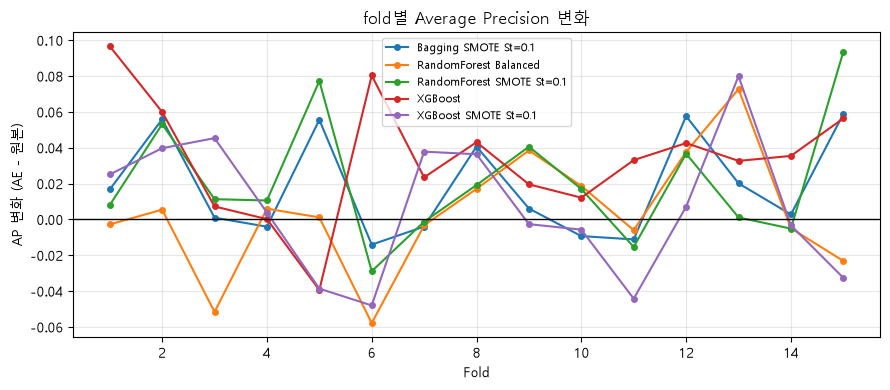

In [13]:
if RUN_AUTOENCODER:
    plt.figure(figsize=(9, 4))
    for model_name, group in delta_df.groupby('Model'):
        plt.plot(range(1, len(group)+1), group['Average Precision'], marker='o', markersize=4, label=model_name)

    plt.axhline(0, color='black', linewidth=1)
    plt.xlabel('Fold')
    plt.ylabel('AP 변화 (AE - 원본)')
    plt.title('fold별 Average Precision 변화')
    plt.legend(fontsize=8)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('오토인코더 생략')

## 4. 검사 물량 기준 Recall@k, Lift

- Threshold 0.5 기준 Precision·Recall은 fold당 불량이 12건뿐이라 흔들림이 큼 → **확률 상위 k%만 검사하는 기준**으로도 확인
- Recall@k: 검사 물량 k%로 전체 불량 중 몇 %를 잡는가
- Precision@k: 검사한 k건 중 몇 건이 실제 불량인가
- Lift: Precision@k를 기저 불량률로 나눈 값으로, 무작위 검사 대비 몇 배 효율인가
- fold 하나는 검증 부분이 1046건뿐이라 상위 0.5%가 5건밖에 안 됨 → **반복 단위로 모은 전체 5230건 기준**으로 계산하고 반복 3회의 평균·표준편차를 확인

In [14]:
inspect_ratios=[0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3]

n_defect=Y.sum()
print(f'전체 {len(Y)}건, 불량 {n_defect}건, 기저 불량률 {n_defect/len(Y):.4%}')

topk_df=pd.concat(
    [recall_at_k_table(Y, proba, inspect_ratios=inspect_ratios,
                       extra_columns={'Model': model_name, 'Feature Set': set_name, 'Repeat': repeat})
     for (model_name, set_name, repeat), proba in oof_proba_store.items()],
    ignore_index=True,
)

topk_summary=topk_df.groupby(['Model', 'Feature Set', '검사 비율']).agg(**{
    '검사 수': ('검사 수', 'first'),
    'Recall@k 평균': ('Recall@k', 'mean'),
    'Recall@k 표준편차': ('Recall@k', 'std'),
    'Precision@k 평균': ('Precision@k', 'mean'),
    'Lift 평균': ('Lift', 'mean'),
})
topk_summary.round(4)

전체 5230건, 불량 60건, 기저 불량률 1.1472%


검사 수  Recall@k 평균  \
Model                     Feature Set    검사 비율                      
Bagging SMOTE St=0.1      AE Recon Error 0.005    26       0.2611   
                                         0.010    52       0.3167   
                                         0.020   105       0.4000   
                                         0.050   262       0.4889   
                                         0.100   523       0.6444   
                                         0.200  1046       0.9389   
                                         0.300  1569       0.9833   
                          원본             0.005    26       0.2500   
                                         0.010    52       0.3056   
                                         0.020   105       0.3778   
                                         0.050   262       0.4889   
                                         0.100   523       0.6944   
                                         0.200  1046       0.9611   
                                         0.300  1569       0.9833   
RandomForest Balanced     AE Recon Error 0.005    26       0.2889   
                                         0.010    52       0.3333   
                                         0.020   105       0.4111   
                                         0.050   262       0.5722   
                                         0.100   523       0.7667   
                                         0.200  1046       0.9500   
                                         0.300  1569       0.9778   
                          원본             0.005    26       0.2833   
                                         0.010    52       0.3222   
                                         0.020   105       0.4056   
                                         0.050   262       0.5333   
                                         0.100   523       0.7889   
                                         0.200  1046       0.9389   
                                         0.300  1569       0.9833   
RandomForest SMOTE St=0.1 AE Recon Error 0.005    26       0.2556   
                                         0.010    52       0.3056   
                                         0.020   105       0.3778   
                                         0.050   262       0.5389   
                                         0.100   523       0.7222   
                                         0.200  1046       0.9500   
                                         0.300  1569       0.9778   
                          원본             0.005    26       0.2556   
                                         0.010    52       0.2833   
                                         0.020   105       0.3444   
                                         0.050   262       0.5111   
                                         0.100   523       0.7111   
                                         0.200  1046       0.9278   
                                         0.300  1569       0.9778   
XGBoost                   AE Recon Error 0.005    26       0.2667   
                                         0.010    52       0.3500   
                                         0.020   105       0.4278   
                                         0.050   262       0.6000   
                                         0.100   523       0.7944   
                                         0.200  1046       0.9556   
                                         0.300  1569       0.9722   
                          원본             0.005    26       0.2556   
                                         0.010    52       0.2889   
                                         0.020   105       0.3944   
                                         0.050   262       0.5444   
                                         0.100   523       0.7500   
                                         0.200  1046       0.8889   
                                         0.300  1569       0.9667   
XGBoost SMOTE St=0.1      AE Recon Error 0.005

### 짝지어 비교 (AE Recon Error - 원본)

- 반복마다 fold 구성이 같으므로 **검사 비율별로 원본과 AE를 짝지어** 볼 수 있음

In [15]:
if RUN_AUTOENCODER:
    topk_pivot=topk_df.pivot_table(index=['Model', '검사 비율', 'Repeat'], columns='Feature Set', values='Recall@k')
    topk_delta=(topk_pivot['AE Recon Error']-topk_pivot['원본']).groupby(['Model', '검사 비율']).agg(['mean', 'std'])
    topk_delta.columns=[f'Recall@k 변화 {stat}' for stat in topk_delta.columns]
    display(topk_delta.round(4))
else:
    print('오토인코더 생략')

Recall@k 변화 mean  Recall@k 변화 std
Model                     검사 비율                                   
Bagging SMOTE St=0.1      0.005            0.0111           0.0096
                          0.010            0.0111           0.0096
                          0.020            0.0222           0.0096
                          0.050            0.0000           0.0333
                          0.100           -0.0500           0.0577
                          0.200           -0.0222           0.0255
                          0.300            0.0000           0.0000
RandomForest Balanced     0.005            0.0056           0.0096
                          0.010            0.0111           0.0096
                          0.020            0.0056           0.0255
                          0.050            0.0389           0.0419
                          0.100           -0.0222           0.0192
                          0.200            0.0111           0.0192
                          0.300           -0.0056           0.0096
RandomForest SMOTE St=0.1 0.005            0.0000           0.0000
                          0.010            0.0222           0.0255
                          0.020            0.0333           0.0167
                          0.050            0.0278           0.0255
                          0.100            0.0111           0.0631
                          0.200            0.0222           0.0255
                          0.300            0.0000           0.0167
XGBoost                   0.005            0.0111           0.0192
                          0.010            0.0611           0.0255
                          0.020            0.0333           0.0167
                          0.050            0.0556           0.0347
                          0.100            0.0444           0.0347
                          0.200            0.0667           0.0289
                          0.300            0.0056           0.0255
XGBoost SMOTE St=0.1      0.005           -0.0111           0.0096
                          0.010            0.0167           0.0167
                          0.020            0.0167           0.0167
                          0.050            0.0056           0.0096
                          0.100            0.0389           0.0096
                          0.200            0.0611           0.0192
                          0.300            0.0333           0.0289

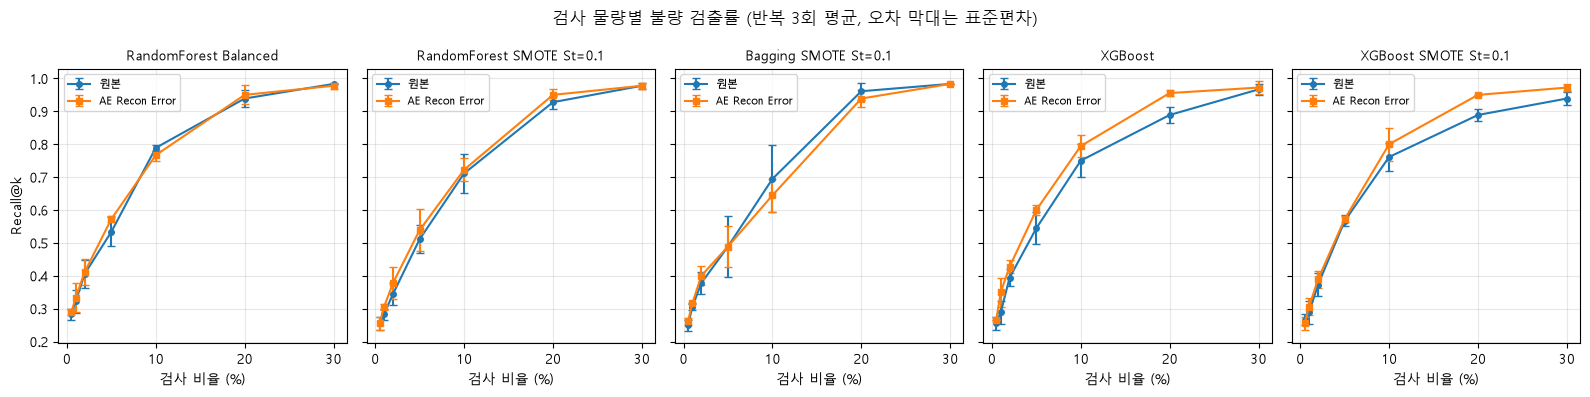

In [16]:
fig, axes=plt.subplots(1, len(model_dict), figsize=(3.2*len(model_dict), 4), sharey=True)
set_names=['원본', 'AE Recon Error'] if RUN_AUTOENCODER else ['원본']

for ax, model_name in zip(axes, model_dict):
    for set_name, marker in zip(set_names, ['o', 's']):
        group=topk_summary.loc[(model_name, set_name)]
        ax.errorbar(group.index*100, group['Recall@k 평균'], yerr=group['Recall@k 표준편차'],
                    marker=marker, markersize=4, capsize=3, label=set_name)

    ax.set_title(model_name, fontsize=10)
    ax.set_xlabel('검사 비율 (%)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Recall@k')
plt.suptitle('검사 물량별 불량 검출률 (반복 3회 평균, 오차 막대는 표준편차)')
plt.tight_layout()
plt.show()

## 결과 저장

In [17]:
fold_df.to_csv('04_6_AutoEncoder_CV_Validation_folds.csv', index=False)
summary_df.to_csv('04_6_AutoEncoder_CV_Validation_summary.csv')
topk_df.to_csv('04_6_AutoEncoder_CV_Validation_topk.csv', index=False)
topk_summary.to_csv('04_6_AutoEncoder_CV_Validation_topk_summary.csv')

# 지표를 바꿀 때 다시 학습하지 않도록 반복별 OOF 확률도 저장
oof_proba_df=pd.DataFrame({f'{model_name} | {set_name} | rep{repeat}': proba
                           for (model_name, set_name, repeat), proba in oof_proba_store.items()}, index=Y.index)
oof_proba_df.insert(0, 'PassOrFail', Y)
oof_proba_df.to_csv('04_6_AutoEncoder_CV_Validation_oof_proba.csv')
print('저장 완료')
summary_df.round(4)

저장 완료


Average Precision mean  \
Model                     Feature Set                              
Bagging SMOTE St=0.1      AE Recon Error                  0.3725   
                          원본                              0.3543   
RandomForest Balanced     AE Recon Error                  0.3963   
                          원본                              0.3931   
RandomForest SMOTE St=0.1 AE Recon Error                  0.3716   
                          원본                              0.3504   
XGBoost                   AE Recon Error                  0.3816   
                          원본                              0.3480   
XGBoost SMOTE St=0.1      AE Recon Error                  0.3596   
                          원본                              0.3529   

                                          Average Precision std  \
Model                     Feature Set                             
Bagging SMOTE St=0.1      AE Recon Error                 0.1173   
                          원본                             0.1227   
RandomForest Balanced     AE Recon Error                 0.1028   
                          원본                             0.1107   
RandomForest SMOTE St=0.1 AE Recon Error                 0.1070   
                          원본                             0.1160   
XGBoost                   AE Recon Error                 0.1100   
                          원본                             0.0958   
XGBoost SMOTE St=0.1      AE Recon Error                 0.1147   
                          원본                             0.1018   

                                          Defect Precision mean  \
Model                     Feature Set                             
Bagging SMOTE St=0.1      AE Recon Error                 0.6259   
                          원본                             0.6700   
RandomForest Balanced     AE Recon Error                 0.2740   
                          원본                             0.2335   
RandomForest SMOTE St=0.1 AE Recon Error                 0.6013   
                          원본                             0.6049   
XGBoost                   AE Recon Error                 0.6230   
                          원본                             0.6555   
XGBoost SMOTE St=0.1      AE Recon Error                 0.5793   
                          원본                             0.5824   

                                          Defect Precision std  \
Model                     Feature Set                            
Bagging SMOTE St=0.1      AE Recon Error                0.2152   
                          원본                            0.2990   
RandomForest Balanced     AE Recon Error                0.0763   
                          원본                            0.0615   
RandomForest SMOTE St=0.1 AE Recon Error                0.2515   
                          원본                            0.2468   
XGBoost                   AE Recon Error                0.2132   
                          원본                            0.2230   
XGBoost SMOTE St=0.1      AE Recon Error                0.2022   
                          원본                            0.2086   

                                          Defect Recall mean  \
Model                     Feature Set                          
Bagging SMOTE St=0.1      AE Recon Error              0.2556   
                          원본                          0.2500   
RandomForest Balanced     AE Recon Error              0.3944   
                          원본                          0.3944   
RandomForest SMOTE St=0.1 AE Recon Error              0.2556   
                          원본                          0.2556   
XGBoost                   AE Recon Error              0.2611   
                          원본                          0.2611   
XGBoost SMOTE St=0.1      AE Recon Error              0.2611   
                          원본                          0.2667   

                                          Defect Reca

## 실험 결과 해석

### 1. 반복 CV 성능 (5-fold × 3반복, fold 15개, 원본 특성)

| 모델 | AP | Recall@2% | Recall@5% | Recall@10% |
| --- | --- | --- | --- | --- |
| RandomForest Balanced | **0.3931 ± 0.1107** | **0.406** | 0.533 | **0.789** |
| Bagging SMOTE St=0.1 | 0.3543 ± 0.1227 | 0.378 | 0.489 | 0.694 |
| XGBoost SMOTE St=0.1 | 0.3529 ± 0.1018 | 0.372 | **0.567** | 0.761 |
| RandomForest SMOTE St=0.1 | 0.3504 ± 0.1160 | 0.344 | 0.511 | 0.711 |
| XGBoost | 0.3480 ± 0.0958 | 0.394 | 0.544 | 0.750 |

- **AP 1위는 RandomForest Balanced(0.3931)이고 2~5위는 0.3480 ~ 0.3543으로 사실상 동률**임. 2~5위 간격 0.006은 fold 표준편차(0.10 ~ 0.12)의 5% 수준이라 순위를 구분할 근거가 없음
- **AP · Recall@2% · Recall@10% 세 지표 모두 RandomForest Balanced가 1위**임. 04_2 OOF에서 보였던 순위 불일치는 **Recall@5% 한 구간으로 축소**됨
- Recall@5%만 XGBoost SMOTE St=0.1(0.567)이 앞서며, 0.533과의 차이는 **불량 2건**임(60건 기준 1건 = 1.7%p). 반복 3회 표준편차가 0.017 ~ 0.044이므로 결정적 근거로 보기 어려움
- 04_1에서 AP만 보고 XGBoost를 후보에서 제외했던 판단은 여전히 근거가 약함. XGBoost는 AP 최하위(0.3480)지만 **Recall@5%는 2위(0.544), Recall@10%는 3위(0.750)** 임

### 2. AE Recon Error 효과 (같은 fold 짝비교)

| 모델 | 원본 AP | +Recon_Error AP | AP 짝차이 평균 | AP 개선 fold | Wilcoxon p (참고) |
| --- | --- | --- | --- | --- | --- |
| XGBoost | 0.3480 ± 0.0958 | 0.3816 ± 0.1100 | **+0.0336** | **14/15** | **0.002** |
| RandomForest SMOTE St=0.1 | 0.3504 ± 0.1160 | 0.3716 ± 0.1070 | +0.0212 | 11/15 | 0.030 |
| Bagging SMOTE St=0.1 | 0.3543 ± 0.1227 | 0.3725 ± 0.1173 | +0.0182 | 10/15 | 0.073 |
| XGBoost SMOTE St=0.1 | 0.3529 ± 0.1018 | 0.3596 ± 0.1147 | +0.0067 | 8/15 | 0.599 |
| RandomForest Balanced | 0.3931 ± 0.1107 | 0.3963 ± 0.1028 | +0.0032 | 8/15 | 0.679 |

검사 물량 기준 Recall@k 짝차이(반복 3회 평균)

| 모델 | Recall@2% 변화 | Recall@5% 변화 | Recall@10% 변화 |
| --- | --- | --- | --- |
| XGBoost | +0.033 | **+0.056** | **+0.044** |
| RandomForest SMOTE St=0.1 | +0.033 | +0.028 | +0.011 |
| XGBoost SMOTE St=0.1 | +0.017 | +0.006 | +0.039 |
| Bagging SMOTE St=0.1 | +0.022 | 0.000 | **-0.050** |
| RandomForest Balanced | +0.006 | +0.039 | **-0.022** |

- **효과가 모델마다 갈림.** XGBoost는 AP +0.0336에 15 fold 중 14개 개선(p=0.002), RandomForest SMOTE St=0.1도 11/15 개선(p=0.030)으로 통계적으로 유의함
- **반면 최종 후보인 RandomForest Balanced는 +0.0032, 8/15, p=0.679로 효과 없음.** fold 표준편차(0.1107)의 3%에 불과한 변동임
- 해석: RandomForest Balanced가 이미 잡아내는 정보를 복원 오차가 **중복 제공**할 뿐이고, XGBoost 계열에는 **없던 정보를 보태는** 것으로 보임. "AE가 쓸모없다"가 아니라 **"RF에는 새로울 것이 없다"** 가 맞는 표현임
- 운영 구간 Recall@k도 같은 패턴. XGBoost는 2 · 5 · 10% 전 구간에서 개선되지만 **RandomForest Balanced는 Recall@10%가 0.022 하락**하고 Bagging은 0.050 하락함
- Threshold 0.5 기준 Defect Recall은 거의 불변임(Bagging 0.2500 → 0.2556, RandomForest Balanced 0.3944 → 0.3944)

### 3. AE 적용 판단

`dashboard/plan.md`의 "성능 개선이 확인될 때만 최종 모델로 적용" 기준에 따르면 **최종 모델에는 넣지 않는 것이 맞음**

- 최종 모델(RandomForest Balanced)의 운영 구간 이득이 **0이거나 음수**임
- 효과 크기(AP +0.0032)가 fold 표준편차(0.1107)의 **3% 수준**임
- AE 효과가 유의한 XGBoost를 쓰더라도 **XGBoost + AE(0.3816) < RandomForest Balanced 원본(0.3931)** 이므로 모델을 갈아탈 유인도 없음
- 제외하면 예측 서버가 오토인코더와 MinMaxScaler를 유지할 필요가 없어져 **파이프라인이 단순해짐**

### 4. 04_5 holdout 값과의 차이

| 모델 | 04_5 holdout AP (원본) | 04_6 CV 평균 AP (원본) |
| --- | --- | --- |
| RandomForest PART_NAME + Balanced | 0.5969 | 0.3931 ± 0.1107 |
| RandomForest PART_NAME + SMOTE St=0.1 | 0.6446 | 0.3504 ± 0.1160 |
| Bagging PART_NAME + SMOTE St=0.1 | 0.6261 | 0.3543 ± 0.1227 |

- 04_2 · 04_5가 쓴 `random_state=0`의 80/20 분할은 **유난히 유리한 분할**이었음. holdout 값이 CV 평균보다 0.20 ~ 0.29 높음
- 분할 시드를 0 ~ 9로 바꿔 확인하면 **`random_state=0`이 10개 중 1위**이고 평균은 **0.3378**임(04_1_1 5-1절). 모델 시드만 바꾼 변동 폭(0.058)의 **6.6배**이므로, 변동의 원인은 **모델이 아니라 test set 구성**임
- 보고할 때는 단일 holdout 값이 아니라 **CV 평균 ± 표준편차**를 함께 기재

### 5. 오토인코더 학습 시 주의

- keras `validation_split=0.2`는 **마지막 20% 행**을 검증셋으로 사용. 이 데이터는 부품별로 뭉쳐 있어서 fold 인덱스를 그대로 넣으면 검증셋이 특정 부품에 치우침
- 섞지 않았을 때 fold 평균 val_loss 0.0033 → 섞은 뒤 0.00026 (04_5와 같은 수준)
- 이번 재실행의 fold별 val_loss는 **0.000109 ~ 0.000179** 범위로 안정적임

### 6. 04_2 OOF 수치와의 차이

같은 모델인데도 04_2의 OOF AP(0.22 ~ 0.27)보다 04_6의 CV AP(0.35 ~ 0.39)가 높은데, **모델이 좋아진 것이 아니라 평가 설계가 다르기 때문**임

| 모델 | 04_2 OOF (fold별 학습 3347건 / 불량 38건) | 04_6 CV (fold별 학습 4184건 / 불량 48건) |
| --- | --- | --- |
| RandomForest PART_NAME + Balanced | 0.2671 | 0.3931 ± 0.1107 |
| RandomForest SMOTE St=0.1 | 0.2599 | 0.3504 ± 0.1160 |
| Bagging SMOTE St=0.1 | 0.2557 | 0.3543 ± 0.1227 |

- 04_2는 학습셋 4184건을 **다시 5-fold로 나눠** fold마다 3347건(불량 38건)으로 학습하고, 04_6은 전체 5230건을 나눠 fold마다 4184건(불량 48건)으로 학습함. 차이의 상당 부분이 **학습 데이터 양**에서 나옴
- 학습량만 바꿔 측정하면 **3347행 0.3387 → 4184행 0.3691**로 +0.030이 설명됨(04_1_1 5-2절). 04_2의 실제 OOF 0.2671과는 **약 0.07 차이가 남으며**, 평가 대상 행 수(4184 vs 5230)와 하이퍼파라미터 차이가 섞여 있음
- 학습 행 1673 → 4184 구간에서 AP가 **0.167 → 0.369로 단조 증가**하므로, 이 표본 크기는 **아직 포화 전**임
- OOF를 한 번에 모아 계산한 AP와 fold별 AP 평균의 차이는 ±0.01 수준이므로 **지표 계산 방식 때문은 아님**
- 최종 모델은 전체 데이터로 학습하므로 **학습량이 배포 조건에 가까운 04_6 쪽이 덜 비관적인 추정**임. 다만 04_6도 하이퍼파라미터를 04_2의 학습셋에서 골랐고 그 데이터가 fold의 검증 부분에 포함되므로 **약간의 낙관 편향**이 남아 있음
- Threshold나 검사 비율 선택은 **04_2 OOF**로, 성능 추정치 보고는 **04_6의 평균과 표준편차**로 사용

### 7. 다음 단계

- 검사 물량 기준으로 최종 모델 확정 (05_Operating_Point)
- 결정한 모델로 검사 물량 k 또는 Threshold 확정 후 `dashboard/plan.md` 갱신
- 전체 데이터로 최종 모델 재학습 및 저장 (06_Final_Model)
- **불량 데이터 추가 확보.** 파라미터 튜닝과 특성 추가로는 0.35 부근에서 움직이지 않음
